# Пространства с различной топологией: теория, уравнения и шейдер

**Сопроводительный разбор к шейдеру [`topology_shader.html`](topology_shader.html).**

Главная мысль: raymarching-шейдер рисует не объект, а **само пространство** с
заданной топологией. Луч движется в *универсальном накрытии* $\tilde X$, а
объекты повторяются по орбитам группы $\Gamma$, так что $X=\tilde X/\Gamma$.
Чтобы это запрограммировать, достаточно одной операции — **свёртки точки в
фундаментальную область** $\mathrm{fold}:\tilde X\to D$ перед вычислением поля
расстояний (SDF).

Ниже выводятся уравнения этой свёртки для **плоского 3-тора $T^3$** и
**периодических структур**, разбираются скрученный тор, орбифолды,
неориентируемые склейки (Мёбиус, Клейн), а кривые геометрии $S^3$, $H^3$ даны
обзором. Эталонная реализация формул и автотесты — в
[`test_topology.py`](test_topology.py); ниже мы их импортируем и используем.

## Оглавление
1. Топология vs геометрия
2. Многообразия и метрика
3. Накрытия и фактор-пространства (ядро подхода)
4. Плоский тор $T^n=\mathbb{R}^n/\Lambda$
5. Скрученный тор (mapping torus)
6. Группы отражений и орбифолды
7. Неориентируемые склейки: Мёбиус, Клейн, $\mathbb{RP}^n$
8. Топологические инварианты
9. Кривизна и три геометрии: $E^3,\,S^3,\,H^3$ (обзор)
10. Мост к raymarching
11. **Тесты** (включая «одна звезда и планета» в $T^3$)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (7, 7),
                     'axes.titlesize': 11, 'font.size': 10})

# эталонные fold-формулы и тороидальная метрика (переиспользуем, не дублируем)
from test_topology import (fold_torus, fold_lattice, fold_twisted, fold_mirror,
                           torus_distance, star_images, count_images_within)
print('fold-функции импортированы из test_topology.py')

fold-функции импортированы из test_topology.py


## 1. Топология vs геометрия

**Геометрия** отвечает за расстояния и углы (метрику $g$), **топология** — за то,
как пространство «склеено», и сохраняется при любых непрерывных деформациях.
Для рендера это разделение ключевое: две поверхности кофейной чашки и бублика
топологически одинаковы (один «дырка»), но по-разному вложены.

Когда мы говорим «шейдер использует пространство с топологией $X$», имеем в виду:
camera-ray стартует в точке $x\in X$ и движется по **геодезической**. Если $X$
получено склейкой из «развёртки» $\tilde X$ (например $\mathbb{R}^3$), то луч
удобно вести в $\tilde X$, а перед каждым опросом сцены сворачивать координату
обратно в одну фундаментальную ячейку. Объект, заданный в одной ячейке,
автоматически виден как **бесконечная периодическая структура** — это и есть
рендер тора.

## 2. Многообразия и метрика

$n$-мерное **многообразие** $X$ локально устроено как $\mathbb{R}^n$: есть атлас
карт $\varphi_\alpha:U_\alpha\to\mathbb{R}^n$. На касательном пространстве задаётся
**риманова метрика** — квадратичная форма

$$ ds^2 = g_{ij}(x)\,dx^i\,dx^j . $$

Длина пути $\gamma$ и геодезические (локально кратчайшие):

$$ L[\gamma]=\int \sqrt{g_{ij}\,\dot\gamma^i\dot\gamma^j}\,dt,
\qquad \ddot\gamma^{\,k}+\Gamma^{k}_{ij}\,\dot\gamma^i\dot\gamma^j=0 ,$$

где $\Gamma^k_{ij}$ — символы Кристоффеля. В **плоском** случае ($g_{ij}=\delta_{ij}$,
$\Gamma=0$) геодезические — прямые: луч в шейдере идёт по прямой, а вся топология
прячется в правило склейки. Именно поэтому плоские факторпространства так дёшевы
для raymarching.

## 3. Накрытия и фактор-пространства — ядро подхода

Пусть группа $\Gamma$ действует на $\tilde X$ **свободно** (без неподвижных точек)
и **разрывно**. Тогда фактор

$$ X=\tilde X/\Gamma,\qquad x\sim\gamma x\ \ \forall\gamma\in\Gamma $$

— многообразие, а проекция $\pi:\tilde X\to X$ — **накрытие**. Элементы $\Gamma$
называются *преобразованиями скольжения* (deck transformations). Если $\tilde X$
односвязно (универсальное накрытие), то

$$ \pi_1(X)\cong\Gamma . $$

**Фундаментальная область** $D\subset\tilde X$ — множество представителей: ровно по
одной точке каждой орбиты (с точностью до границы), так что

$$ \tilde X=\bigcup_{\gamma\in\Gamma}\gamma D,\qquad
   \mathrm{int}(\gamma D)\cap\mathrm{int}(D)=\varnothing\ (\gamma\neq e). $$

**Главное для шейдера.** Чтобы вычислить сцену в точке $x\in X$, берём любого
представителя $p\in\tilde X$ и сворачиваем его в $D$:

$$ \boxed{\ \mathrm{fold}:\tilde X\to D,\qquad \mathrm{fold}(\gamma p)=\mathrm{fold}(p)\ } $$

Далее опрашиваем поле расстояний от содержимого ячейки $D$. Разные группы
$\Gamma$ → разные топологии при **одном и том же** коде рендера. Ниже выписываем
$\mathrm{fold}$ для конкретных $\Gamma$.

## 4. Плоский тор $T^n=\mathbb{R}^n/\Lambda$

Возьмём $\tilde X=\mathbb{R}^n$ и группу **трансляций по решётке**
$\Lambda=A\mathbb{Z}^n$, где столбцы матрицы $A=[\,\mathbf a_1\ \dots\ \mathbf a_n\,]$ —
базисные векторы. Тогда $\Gamma\cong\mathbb{Z}^n$ и

$$ T^n=\mathbb{R}^n/\Lambda,\qquad \mathbf p\sim \mathbf p+A\mathbf m\ \ (\mathbf m\in\mathbb{Z}^n). $$

Точка с координатами $\mathbf c$ в базисе решётки есть $\mathbf p=A\mathbf c$, значит
$\mathbf c=A^{-1}\mathbf p$, а ближайший узел — $A\cdot\mathrm{round}(\mathbf c)$.
Отсюда **общая формула свёртки**:

$$ \boxed{\ \mathrm{fold}_\Lambda(\mathbf p)=\mathbf p-A\,\mathrm{round}\!\big(A^{-1}\mathbf p\big)\ } $$

Для **кубической** решётки $A=L\,I$ она упрощается до периодического остатка —
ровно то, что в шейдерах называют *domain repetition*:

$$ \mathbf q=\mathrm{mod}\!\big(\mathbf p+\tfrac{L}{2},\,L\big)-\tfrac{L}{2}
   \;=\;\mathbf p-L\,\mathrm{round}(\mathbf p/L). $$

Свойства: метрика плоская, кривизна $K=0$, $\pi_1(T^n)=\mathbb{Z}^n$,
эйлерова характеристика $\chi(T^n)=0$. Геодезические — прямые; луч в накрытии
прямой, а на торе «наматывается». Ниже — иллюстрация для $T^2$ и проверка, что
$\mathrm{fold}$ действительно загоняет любую точку в ячейку.

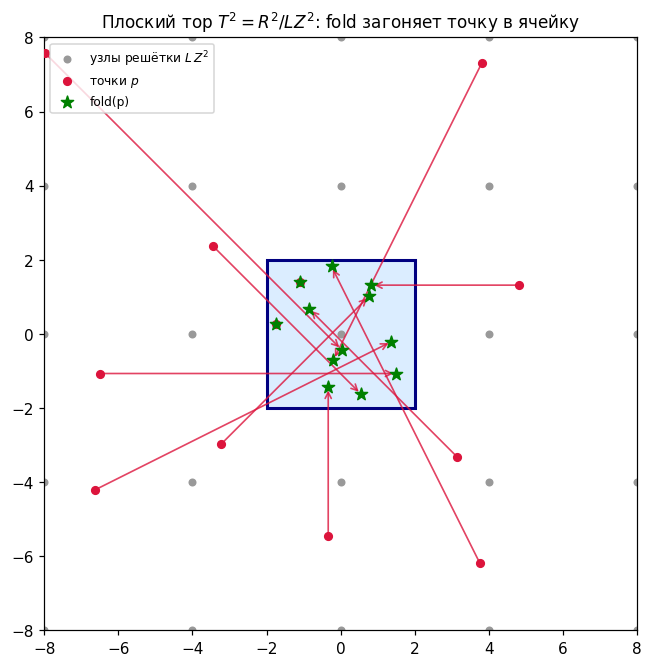

max|fold(p+Ln)-fold(p)| = 1.7763568394002505e-15


In [2]:
L = 4.0
fig, ax = plt.subplots(figsize=(7, 7))
g = np.arange(-2, 3)
GX, GY = np.meshgrid(g * L, g * L)
ax.scatter(GX, GY, c='0.6', s=18, zorder=2, label=r'узлы решётки $L\,Z^2$')
ax.add_patch(plt.Rectangle((-L/2, -L/2), L, L, fc=(0.6, 0.8, 1, 0.35),
                           ec='navy', lw=2, zorder=1))
rng = np.random.default_rng(3)
P = rng.uniform(-2*L, 2*L, size=(12, 2))
Q = fold_torus(P, L)
for p, q in zip(P, Q):
    ax.annotate('', xy=q, xytext=p,
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.1, alpha=0.8))
ax.scatter(P[:, 0], P[:, 1], c='crimson', s=25, zorder=3, label='точки $p$')
ax.scatter(Q[:, 0], Q[:, 1], c='green', s=70, marker='*', zorder=4, label='fold(p)')
ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(-2*L, 2*L); ax.set_ylim(-2*L, 2*L)
ax.set_title('Плоский тор $T^2=R^2/L Z^2$: fold загоняет точку в ячейку')
plt.show()

# численная проверка периодичности fold
p = rng.uniform(-10, 10, (5, 3)); n = rng.integers(-3, 4, (5, 3))
print('max|fold(p+Ln)-fold(p)| =', np.abs(fold_torus(p + L*n, L) - fold_torus(p, L)).max())

## 5. Скрученный тор (mapping torus)

Не всякое плоское компактное многообразие — обычный тор. Возьмём слой
$\mathbb{R}^2$ и склеим его «через поворот» при сдвиге на $L$ вдоль $x$. Это
**mapping torus** отображения-монодромии $\varphi\in O(2)$:

$$ M_\varphi=\big(\mathbb{R}^2\times\mathbb{R}\big)\big/\!\sim,\qquad
   (\mathbf y,\,t)\ \sim\ (\varphi\,\mathbf y,\ t+L). $$

Чтобы фактор был **плоским многообразием** (теорема Бибербаха), $\varphi$ должна
быть изометрией, сохраняющей решётку слоя. Возьмём поворот на $180^\circ$:

$$ \varphi=R_x(\pi):\ (y,z)\mapsto(-y,-z),\qquad \varphi^2=I . $$

Тогда истинный период вдоль $x$ равен $2L$, а свёртка такая: сначала обычный
$\mathrm{fold}$, затем — если индекс ячейки $i_x=\lfloor (x+L/2)/L\rfloor$ нечётный —
поворот поперечной плоскости:

$$ \mathbf q=\mathrm{fold}_{T^3}(\mathbf p),\qquad
   (q_y,q_z)\mapsto(-q_y,-q_z)\ \text{ при } i_x\ \text{нечётном}. $$

Так как $\det\varphi=+1$, пространство **ориентируемо** (при $\det\varphi=-1$
получили бы неориентируемое). Ниже — схема: ячейки переворачиваются через одну.

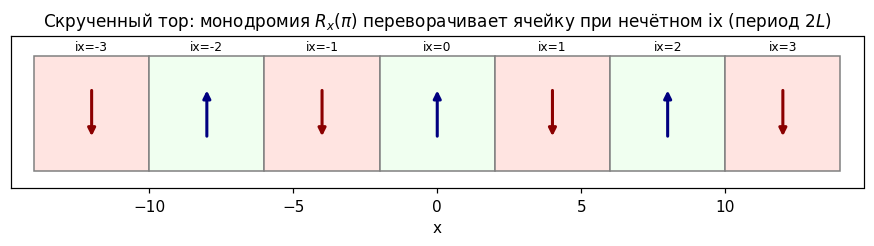

период 2L: True


In [3]:
L = 4.0
fig, ax = plt.subplots(figsize=(10, 3))
for ix in range(-3, 4):
    x0 = ix * L
    even = (ix % 2 == 0)
    ax.add_patch(plt.Rectangle((x0 - L/2, -L/2), L, L,
                 fc=('honeydew' if even else 'mistyrose'), ec='0.5'))
    ax.annotate('', xy=(x0, 0.9 if even else -0.9), xytext=(x0, -0.9 if even else 0.9),
                arrowprops=dict(arrowstyle='-|>', color='navy' if even else 'darkred', lw=2))
    ax.text(x0, L/2 + 0.2, f'ix={ix}', ha='center', fontsize=8)
ax.set_aspect('equal'); ax.set_yticks([]); ax.set_xlabel('x')
ax.set_xlim(-3.7*L, 3.7*L); ax.set_ylim(-L/2 - 0.6, L/2 + 0.7)
ax.set_title(r'Скрученный тор: монодромия $R_x(\pi)$ переворачивает ячейку при нечётном ix (период $2L$)')
plt.show()
print('период 2L:', np.allclose(fold_twisted(p + np.array([2*L,0,0]), L), fold_twisted(p, L)))

## 6. Группы отражений и орбифолды

Если в $\Gamma$ добавить **отражения**, действие перестаёт быть свободным: на
зеркалах есть неподвижные точки, и фактор — уже не многообразие, а **орбифолд**.
Простейший пример — группа, порождённая отражениями в гранях ячейки (это
частный случай **группы Кокстера**). Свёртка — треугольная волна:

$$ \boxed{\ \mathrm{fold}_{\text{mirror}}(\mathbf p)=\big|\,\mathrm{mod}(\mathbf p,\,2L)-L\,\big|-\tfrac{L}{2}\ } $$

Модуль $|\cdot|$ и создаёт зеркала. В кристаллографии полный список таких групп
в $\mathbb{R}^2$ — **17 wallpaper-групп**, в $\mathbb{R}^3$ — **230
пространственных групп**: каждая задаёт свой орбифолд $\mathbb{R}^3/\Gamma$ и свой
тип периодической структуры. Ниже — одномерный срез: видно, как точка
«отражается» от стенок фундаментального отрезка.

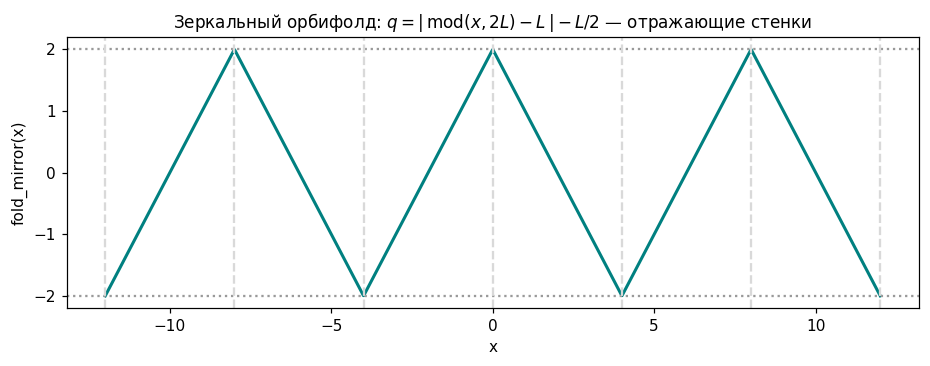

In [4]:
L = 4.0
x = np.linspace(-3*L, 3*L, 2000)
q = np.abs(np.mod(x, 2*L) - L) - L/2
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(x, q, lw=2, color='teal')
ax.axhline(L/2, ls=':', c='0.6'); ax.axhline(-L/2, ls=':', c='0.6')
for k in range(-3, 4):
    ax.axvline(k*L, ls='--', c='0.85')
ax.set_xlabel('x'); ax.set_ylabel('fold_mirror(x)')
ax.set_title(r'Зеркальный орбифолд: $q=|\,\mathrm{mod}(x,2L)-L\,|-L/2$ — отражающие стенки')
plt.show()

## 7. Неориентируемые склейки: Мёбиус, Клейн, $\mathbb{RP}^n$

Если при склейке менять ориентацию, получаем **неориентируемые** пространства.

- **Лента Мёбиуса:** полоса $[0,1]\times\mathbb{R}$ с отождествлением
  $(0,y)\sim(1,-y)$. Край — одна окружность, сторона — одна.
- **Бутылка Клейна** $K$: квадрат с $(x,0)\sim(x,1)$ и $(0,y)\sim(1,-y)$; как
  фактор плоскости — группа, порождённая трансляцией и *скользящим отражением*
  $g(x,y)=(x+\tfrac12,-y)$. Фундаментальная группа
  $\pi_1(K)=\langle a,b\mid abab^{-1}\rangle$.
- **Проективные пространства** $\mathbb{RP}^n=S^n/\{\pm1\}$: отождествление
  антиподов $\mathbf x\sim-\mathbf x$.

Слово склейки многоугольника кодирует топологию: тор — $aba^{-1}b^{-1}$,
бутылка Клейна — $abab^{-1}$, $\mathbb{RP}^2$ — $abab$. Ниже — 3D-погружения
Мёбиуса и Клейна и диаграммы склейки рёбер квадрата.

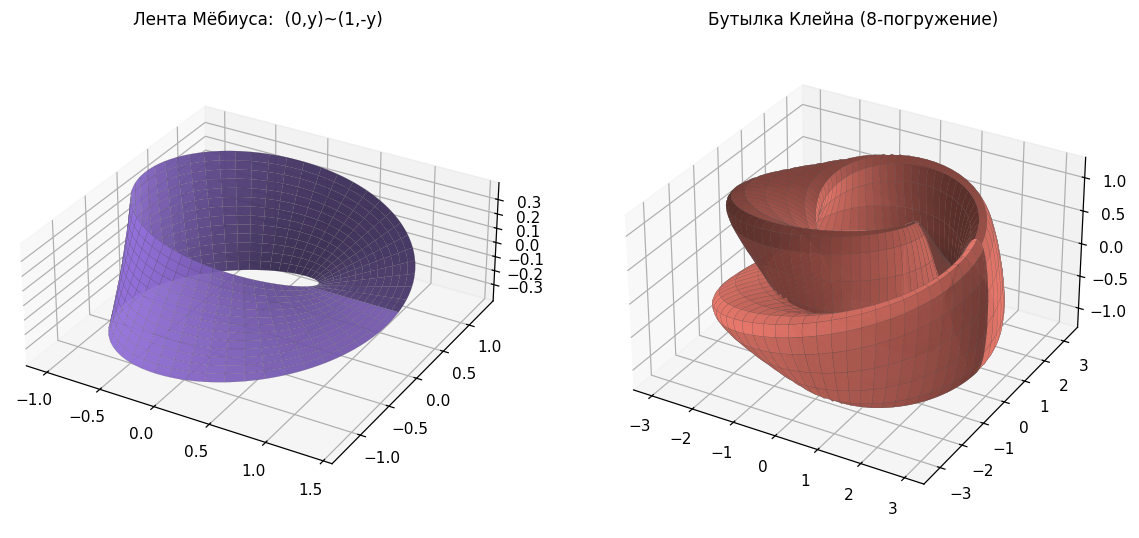

In [5]:
fig = plt.figure(figsize=(11, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
u = np.linspace(0, 2*np.pi, 160); v = np.linspace(-0.4, 0.4, 14)
U, V = np.meshgrid(u, v)
X = (1 + V*np.cos(U/2))*np.cos(U)
Y = (1 + V*np.cos(U/2))*np.sin(U)
Z = V*np.sin(U/2)
ax1.plot_surface(X, Y, Z, rstride=1, cstride=3, color='mediumpurple',
                 alpha=0.95, edgecolor='0.3', linewidth=0.1)
ax1.set_title('Лента Мёбиуса:  (0,y)~(1,-y)'); ax1.set_box_aspect((1, 1, 0.4))

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
u = np.linspace(0, 2*np.pi, 200); v = np.linspace(0, 2*np.pi, 80)
U, V = np.meshgrid(u, v); r = 2.0
X = (r + np.cos(U/2)*np.sin(V) - np.sin(U/2)*np.sin(2*V))*np.cos(U)
Y = (r + np.cos(U/2)*np.sin(V) - np.sin(U/2)*np.sin(2*V))*np.sin(U)
Z = np.sin(U/2)*np.sin(V) + np.cos(U/2)*np.sin(2*V)
ax2.plot_surface(X, Y, Z, rstride=3, cstride=3, color='salmon',
                 alpha=0.9, edgecolor='0.3', linewidth=0.1)
ax2.set_title('Бутылка Клейна (8-погружение)'); ax2.set_box_aspect((1, 1, 0.6))
plt.tight_layout(); plt.show()

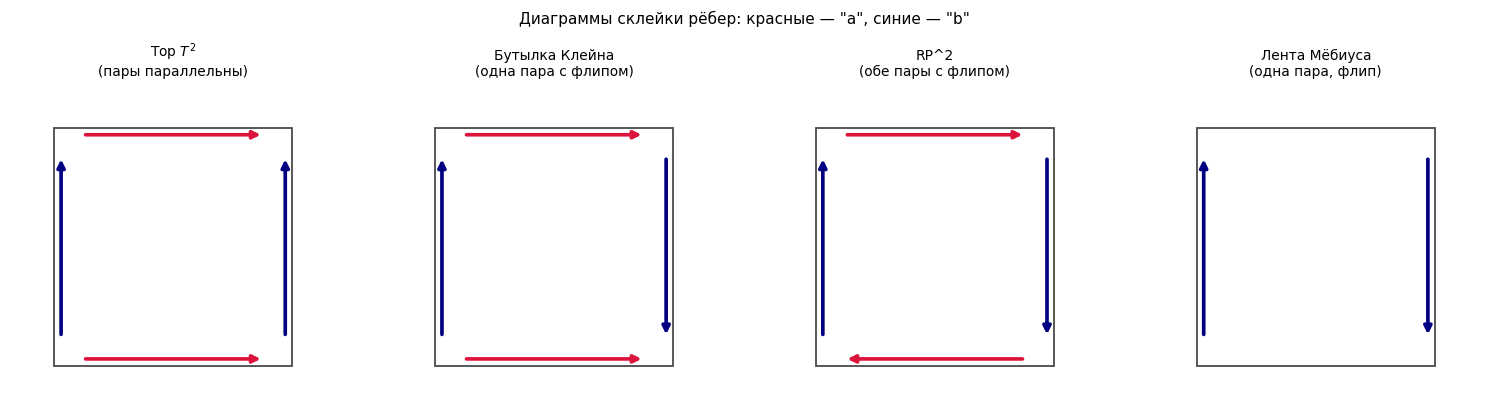

In [6]:
def square_diagram(ax, title, top=None, bot=None, left=None, right=None):
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fc='none', ec='0.3', lw=1.2))
    def harrow(y, sign):
        x0, x1 = (0.12, 0.88) if sign > 0 else (0.88, 0.12)
        ax.annotate('', xy=(x1, y), xytext=(x0, y),
                    arrowprops=dict(arrowstyle='-|>', color='crimson', lw=2.4))
    def varrow(x, sign):
        y0, y1 = (0.12, 0.88) if sign > 0 else (0.88, 0.12)
        ax.annotate('', xy=(x, y1), xytext=(x, y0),
                    arrowprops=dict(arrowstyle='-|>', color='navy', lw=2.4))
    if top is not None:   harrow(0.97, top)
    if bot is not None:   harrow(0.03, bot)
    if left is not None:  varrow(0.03, left)
    if right is not None: varrow(0.97, right)
    ax.set_xlim(-0.18, 1.18); ax.set_ylim(-0.18, 1.18)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title, fontsize=9)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.7))
square_diagram(axes[0], 'Тор $T^2$\n(пары параллельны)', top=+1, bot=+1, left=+1, right=+1)
square_diagram(axes[1], 'Бутылка Клейна\n(одна пара с флипом)', top=+1, bot=+1, left=+1, right=-1)
square_diagram(axes[2], 'RP^2\n(обе пары с флипом)', top=+1, bot=-1, left=+1, right=-1)
square_diagram(axes[3], 'Лента Мёбиуса\n(одна пара, флип)', left=+1, right=-1)
plt.suptitle('Диаграммы склейки рёбер: красные — "a", синие — "b"', y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

## 8. Топологические инварианты

Как отличать пространства? Инвариантами, не меняющимися при гомеоморфизме.

- **Фундаментальная группа** $\pi_1(X)$ — классы петель: $\pi_1(T^n)=\mathbb{Z}^n$,
  $\pi_1(K)=\langle a,b\mid abab^{-1}\rangle$, $\pi_1(\mathbb{RP}^2)=\mathbb{Z}/2$.
- **Эйлерова характеристика** $\chi$. Для замкнутой ориентируемой поверхности
  рода $g$ (число «ручек»):

  $$ \chi = 2 - 2g . $$

  Связная сумма: $\chi(A\#B)=\chi(A)+\chi(B)-2$. Сфера $\chi=2$, тор $\chi=0$,
  крендель (род 2) $\chi=-2$.
- **Ориентируемость** — есть ли непрерывный выбор «правой тройки»; ломается у
  Мёбиуса/Клейна.
- **Слово склейки** многоугольника $a_1b_1a_1^{-1}b_1^{-1}\cdots a_gb_ga_g^{-1}b_g^{-1}$
  — нормальная форма ориентируемой поверхности рода $g$.

## 9. Кривизна и три геометрии: $E^3,\,S^3,\,H^3$ (обзор)

Знак кривизны $K$ разделяет три однородные геометрии. Глобально это связано с
топологией через **теорему Гаусса–Бонне**:

$$ \int_M K\,dA = 2\pi\,\chi(M). $$

- **Евклидова** $E^3$ ($K=0$): всё, что выше (торы, орбифолды). Луч прямой.
- **Сферическая** $S^3=\{q\in\mathbb{H}:|q|=1\}$ ($K>0$). Геодезические — большие
  окружности; расстояние $d(p,q)=\arccos\langle p,q\rangle$. Изометрии — пары
  единичных кватернионов $q\mapsto u\,q\,\bar v$ (группа $\mathrm{Spin}(4)$).
  Удобная карта — стереографическая проекция

  $$ \sigma(x_1,x_2,x_3,x_4)=\frac{(x_1,x_2,x_3)}{1-x_4}. $$

  Расслоение Хопфа $S^1\hookrightarrow S^3\to S^2$ заполняет $S^3$ линкованными
  окружностями.
- **Гиперболическая** $H^3$ ($K<0$). Модель шара Пуанкаре и полупространства:

  $$ ds^2=\frac{4\,|d\mathbf x|^2}{(1-|\mathbf x|^2)^2},\qquad
     ds^2=\frac{dx^2+dy^2+dz^2}{z^2}. $$

  Геодезические — дуги/прямые, перпендикулярные границе; изометрии —
  преобразования Мёбиуса $\mathrm{PSL}(2,\mathbb{C})$; расстояние от центра
  $d(0,\mathbf x)=2\,\operatorname{artanh}|\mathbf x|$.

**Почему в шейдере это дороже** и мы оставляем кривые как обзор: геодезическая
искривлена ($\Gamma^k_{ij}\neq0$), и луч нельзя вести простым $\mathbf p+t\mathbf d$ —
нужно либо интегрировать уравнение геодезических, либо работать в модельных
координатах с пересчётом метрики на каждом шаге. Ниже — две иллюстрации:
стереографическая проекция (для $S^3$ — то же на размерность выше) и геодезические
диска Пуанкаре.

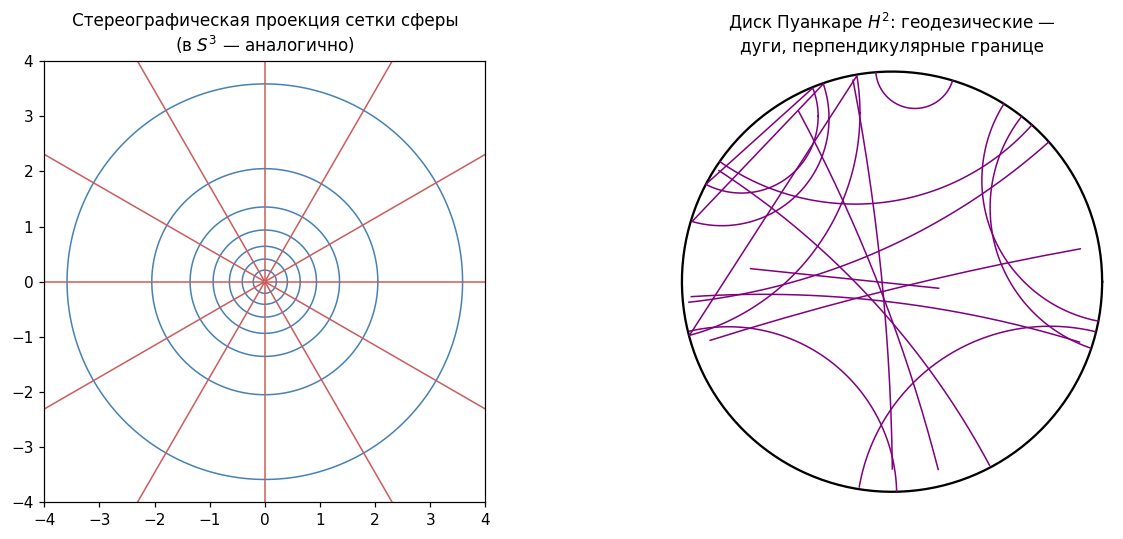

In [7]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
def stereo(theta, phi):
    z = np.cos(theta); s = np.sin(theta)
    return s*np.cos(phi)/(1 - z + 1e-9), s*np.sin(phi)/(1 - z + 1e-9)
for theta in np.linspace(0.18, np.pi - 0.05, 9):
    phi = np.linspace(0, 2*np.pi, 240)
    X, Y = stereo(theta*np.ones_like(phi), phi); ax1.plot(X, Y, c='steelblue', lw=1)
for phi in np.linspace(0, 2*np.pi, 12, endpoint=False):
    theta = np.linspace(0.05, np.pi - 0.05, 240)
    X, Y = stereo(theta, phi*np.ones_like(theta)); ax1.plot(X, Y, c='indianred', lw=1)
ax1.set_aspect('equal'); ax1.set_xlim(-4, 4); ax1.set_ylim(-4, 4)
ax1.set_title('Стереографическая проекция сетки сферы\n(в $S^3$ — аналогично)')

ax2 = fig.add_subplot(1, 2, 2)
tt = np.linspace(0, 2*np.pi, 300); ax2.plot(np.cos(tt), np.sin(tt), 'k', lw=1.5)
def geodesic(a, b):
    d = (b - a)/2.0
    if abs(np.sin(d)) < 1e-6:
        return np.array([np.cos(a), np.cos(b)]), np.array([np.sin(a), np.sin(b)])
    m = (a + b)/2.0
    c = np.array([np.cos(m), np.sin(m)])/np.cos(d); r = abs(np.tan(d))
    ang = np.linspace(0, 2*np.pi, 500)
    X = c[0] + r*np.cos(ang); Y = c[1] + r*np.sin(ang)
    inside = X**2 + Y**2 <= 1.0 + 1e-9
    return X[inside], Y[inside]
rng = np.random.default_rng(1)
for _ in range(16):
    a, b = rng.uniform(0, 2*np.pi, 2)
    X, Y = geodesic(a, b); ax2.plot(X, Y, c='purple', lw=1)
ax2.set_aspect('equal'); ax2.set_xlim(-1.05, 1.05); ax2.set_ylim(-1.05, 1.05); ax2.axis('off')
ax2.set_title('Диск Пуанкаре $H^2$: геодезические —\nдуги, перпендикулярные границе')
plt.tight_layout(); plt.show()

## 10. Мост к raymarching

Сцена задаётся **функцией расстояния со знаком** (SDF / distance estimator)
$\mathrm{DE}(\mathbf p)$ — расстоянием до ближайшей поверхности. Примитивы:

$$ \mathrm{sphere}(\mathbf p)=|\mathbf p|-R,\qquad
   \mathrm{torus}(\mathbf p)=\Big|\big(\sqrt{p_x^2+p_z^2}-R,\ p_y\big)\Big|-r, $$

объединение — $\min$, пересечение — $\max$. **Топология входит ровно одной
строкой** — свёрткой координаты в фундаментальную область:

$$ \boxed{\ \mathrm{DE}(\mathbf p)=\mathrm{DE}_{D}\big(\mathrm{fold}(\mathbf p)\big)\ } $$

Луч ведём **sphere tracing**: на каждом шаге можно безопасно продвинуться на
текущее расстояние

$$ t_{k+1}=t_k+\mathrm{DE}(\mathbf p_k),\qquad \mathbf p_k=\mathbf o+t_k\mathbf d, $$

пока $\mathrm{DE}<\varepsilon$ (попали) или $t>t_{\max}$. Нормаль — численный градиент

$$ \mathbf n=\frac{\nabla\mathrm{DE}}{|\nabla\mathrm{DE}|},\qquad
   \partial_i\mathrm{DE}\approx\frac{\mathrm{DE}(\mathbf p+\varepsilon\mathbf e_i)-\mathrm{DE}(\mathbf p-\varepsilon\mathbf e_i)}{2\varepsilon}. $$

Этот псевдокод дословно переносится в GLSL шейдера
[`topology_shader.html`](topology_shader.html), где `fold` для режимов
`1/2/3` — это в точности `fold_torus`, `fold_mirror`, `fold_twisted` из раздела 4–6.

## 11. Тесты

Сначала прогоняем автотесты fold-формул из `test_topology.py` (периодичность,
идемпотентность, попадание в область, монодромия скрученного тора, метрика и
подсчёт образов). Затем — отдельный наглядный сценарий **«одна звезда и
планета»**.

In [8]:
import test_topology as tt
ok = tt._run_all()
assert ok, 'Есть упавшие тесты!'  

  PASS  test_fold_idempotent
  PASS  test_fold_in_domain
  PASS  test_fold_periodic
  PASS  test_general_lattice_matches_cubic
  PASS  test_general_lattice_periodic
  PASS  test_image_count_density
  PASS  test_mirror_in_domain
  PASS  test_mirror_reflection
  PASS  test_one_planet_one_star_scene
  PASS  test_star_images_fold_back
  PASS  test_torus_distance_properties
  PASS  test_twisted_monodromy
  PASS  test_twisted_period_2L

13/13 тестов прошло.


### 11.1. «Одна планета и звезда» в $T^3$ — космическая кристаллография

Поместим в фундаментальную ячейку **одну** звезду $\mathbf s$ и **одну** планету
(наблюдателя) $\mathbf o$. Поскольку пространство периодично, наблюдатель видит
звезду не один раз, а как **решётку образов**

$$ \{\mathbf s + L\mathbf k:\ \mathbf k\in\mathbb{Z}^3\}, $$

каждый из которых соответствует своему обходу тора (своей геодезической в
накрытии). Это и есть «зеркальный зал» — реальный наблюдаемый эффект, по которому
в космологии ищут топологию Вселенной. Ближайший образ задаёт тороидальную
метрику $d_T(\mathbf o,\mathbf s)=\min_{\mathbf k}|\mathbf o-\mathbf s-L\mathbf k|$.

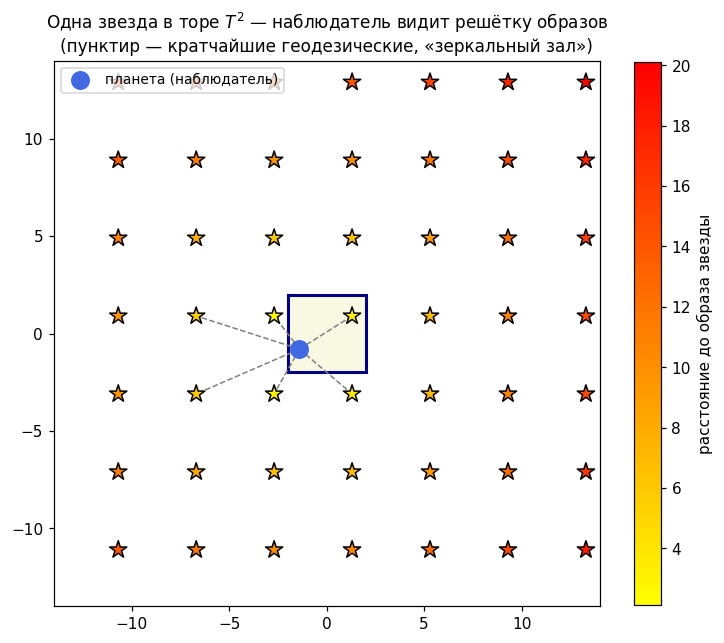

ближайший образ = 2.1401 | d_T(planet,star) = 2.1401


In [9]:
L = 4.0
planet = np.array([-1.4, -0.8])
star   = np.array([ 1.3,  0.9])

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_patch(plt.Rectangle((-L/2, -L/2), L, L, fc=(0.96, 0.96, 0.8, 0.55),
                           ec='navy', lw=2, zorder=1))
g = np.arange(-3, 4); KX, KY = np.meshgrid(g, g)
imgs = star[None, :] + L*np.stack([KX.ravel(), KY.ravel()], -1)
d = np.linalg.norm(imgs - planet, axis=1)
order = np.argsort(d)
sc = ax.scatter(imgs[:, 0], imgs[:, 1], c=d, cmap='autumn_r', s=140,
                marker='*', edgecolor='k', zorder=3)
for idx in order[:6]:
    ax.plot([planet[0], imgs[idx, 0]], [planet[1], imgs[idx, 1]],
            c='gray', lw=1, ls='--', zorder=2)
ax.scatter(*planet, c='royalblue', s=130, zorder=4, label='планета (наблюдатель)')
plt.colorbar(sc, label='расстояние до образа звезды', shrink=0.8)
ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-3.5*L, 3.5*L); ax.set_ylim(-3.5*L, 3.5*L)
ax.set_title('Одна звезда в торе $T^2$ — наблюдатель видит решётку образов\n'
             '(пунктир — кратчайшие геодезические, «зеркальный зал»)')
plt.show()

print('ближайший образ =', d.min().round(4),
      '| d_T(planet,star) =', float(torus_distance(planet, star, L)).__round__(4))

Количественная проверка в 3D: число образов одной звезды внутри «горизонта»
радиуса $R$ растёт как объём шара, делённый на объём ячейки (плотность ровно один
образ на ячейку):

$$ N(R)\ \approx\ \frac{\tfrac{4}{3}\pi R^3}{L^3}. $$

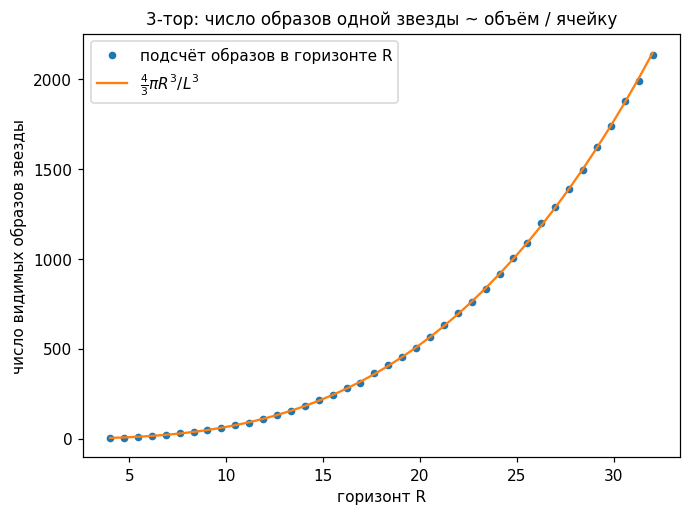

относительная ошибка при R=8L: 0.005


In [10]:
L = 4.0
observer = np.array([0.3, -0.2, 0.1])
star3 = np.array([1.0, 0.5, -0.7])
Rs = np.linspace(L, 8*L, 40)
counts = np.array([count_images_within(observer, star3, R, L) for R in Rs])
theory = (4/3)*np.pi*Rs**3 / L**3

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(Rs, counts, 'o', ms=4, label='подсчёт образов в горизонте R')
ax.plot(Rs, theory, '-', label=r'$\frac{4}{3}\pi R^3 / L^3$')
ax.set_xlabel('горизонт R'); ax.set_ylabel('число видимых образов звезды')
ax.set_title('3-тор: число образов одной звезды ~ объём / ячейку')
ax.legend(); plt.show()
print('относительная ошибка при R=8L:', round(abs(counts[-1]-theory[-1])/theory[-1], 3))

### Итог

Одна формула $\mathrm{fold}$ задаёт топологию; меняя $\Gamma$, получаем тор,
скрученный тор или орбифолд **тем же кодом рендера**. Интерактивная демонстрация
(включая сцену «звезда + планета») — в [`topology_shader.html`](topology_shader.html):
клавиши `1/2/3` переключают $\Gamma$, `4` — сцену со звездой и планетой.